In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 🎯 Notebook Exploratoire — Phase 1

## Objectif
Vérifier que le dataset respecte les exigences du cadrage :
- ✅ Classification supervisée binaire
- ✅ ≥ 10,000 lignes
- ✅ ≥ 8 features
- ✅ Déséquilibre 5-25% (classe minoritaire)
- ✅ Mix de variables numériques + catégorielles

---

## Table des matières
1. Chargement et exploration basique
2. Analyse du déséquilibre de classe
3. Visualisations
4. Résumé et validation

In [11]:
# ==========================================
# 1. CHARGER LE DATASET
# ==========================================

import os
os.chdir(r"c:\Users\PC\PROJET_AURORAS")

df = pd.read_csv("data/dataset.csv")

print("=" * 60)
print("ANALYSE DU DÉSÉQUILIBRE DE CLASSE")
print("=" * 60)

print(f"\n📊 DIMENSIONS DU DATASET")
print(f"{'─' * 60}")
print(f"Nombre de lignes  : {df.shape[0]:,}")
print(f"Nombre de colonnes: {df.shape[1]}")
print(f"\nColonnes disponibles :")
print(df.columns.tolist())

ANALYSE DU DÉSÉQUILIBRE DE CLASSE

📊 DIMENSIONS DU DATASET
────────────────────────────────────────────────────────────
Nombre de lignes  : 13,992
Nombre de colonnes: 13

Colonnes disponibles :
['timestamp', 'kp_index', 'ap_index', 'solar_wind_speed', 'solar_wind_density', 'bz_component', 'month', 'season', 'hour_interval', 'is_solar_maximum', 'kp_previous_interval', 'bz_negative', 'aurora_visible']


## 1️⃣ CHARGEMENT ET EXPLORATION BASIQUE

Commençons par charger le dataset et vérifier sa structure.

In [12]:
# ==========================================
# 2. COMPTER LES CLASSES
# ==========================================

print(f"\n📊 DISTRIBUTION BRUTE")
print(f"{'─' * 60}")

class_counts = df["aurora_visible"].value_counts().sort_index()
print(class_counts)


📊 DISTRIBUTION BRUTE
────────────────────────────────────────────────────────────
aurora_visible
0    13722
1      270
Name: count, dtype: int64


In [13]:

# Info détaillée
print("\n📋 INFO DÉTAILLÉE DU DATASET")
print(f"{'─' * 60}")
print("Types de données et NaN :")
print(df.info())
print(f"\n\n{'─' * 60}")
print("Premiers aperçus :")
print(df.head(10))



📋 INFO DÉTAILLÉE DU DATASET
────────────────────────────────────────────────────────────
Types de données et NaN :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13992 entries, 0 to 13991
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             13992 non-null  object 
 1   kp_index              13992 non-null  float64
 2   ap_index              13992 non-null  float64
 3   solar_wind_speed      13992 non-null  float64
 4   solar_wind_density    13821 non-null  float64
 5   bz_component          13909 non-null  float64
 6   month                 13992 non-null  int64  
 7   season                13992 non-null  object 
 8   hour_interval         13992 non-null  object 
 9   is_solar_maximum      13992 non-null  int64  
 10  kp_previous_interval  13991 non-null  float64
 11  bz_negative           13992 non-null  int64  
 12  aurora_visible        13992 non-null  int64  
dtypes: fl

### Info de base du dataset

Vérifions les dimensions et les types de données :

In [14]:
# ==========================================
# 3. CALCULER LES POURCENTAGES
# ==========================================

print(f"\n📈 POURCENTAGES")
print(f"{'─' * 60}")

total_lines = len(df)
print(f"Nombre total de lignes : {total_lines}")

class_percentages = df["aurora_visible"].value_counts(normalize=True).sort_index() * 100

for class_label, percentage in class_percentages.items():
    class_name = "❌ Pas d'aurores (Kp < 5)" if class_label == 0 else "✅ Aurores visibles (Kp ≥ 5)"
    count = class_counts[class_label]
    print(f"  Classe {class_label} ({class_name})")
    print(f"    → {count:,} lignes ({percentage:.2f}%)")



📈 POURCENTAGES
────────────────────────────────────────────────────────────
Nombre total de lignes : 13992
  Classe 0 (❌ Pas d'aurores (Kp < 5))
    → 13,722 lignes (98.07%)
  Classe 1 (✅ Aurores visibles (Kp ≥ 5))
    → 270 lignes (1.93%)


In [15]:

# Vérification des exigences
print(f"\n\n✅ VÉRIFICATION DES EXIGENCES DU CADRAGE")
print(f"{'─' * 60}")

requirements = {
    "Type de problème": ("Classification binaire", "aurora_visible" in df.columns and len(df['aurora_visible'].unique()) == 2),
    "Taille minimale": (f"≥ 10,000 lignes (nous avons {df.shape[0]:,})", df.shape[0] >= 10000),
    "Nombre de features": (f"≥ 8 features (nous avons {df.shape[1]})", df.shape[1] >= 8),
    "Variable cible": ("aurora_visible (binaire)", "aurora_visible" in df.columns)
}

for requirement, (description, status) in requirements.items():
    status_icon = "✅" if status else "❌"
    print(f"{status_icon} {requirement}: {description}")




✅ VÉRIFICATION DES EXIGENCES DU CADRAGE
────────────────────────────────────────────────────────────
✅ Type de problème: Classification binaire
✅ Taille minimale: ≥ 10,000 lignes (nous avons 13,992)
✅ Nombre de features: ≥ 8 features (nous avons 13)
✅ Variable cible: aurora_visible (binaire)


## 2️⃣ ANALYSE DU DÉSÉQUILIBRE DE CLASSE

C'est l'élément **clé** de la Phase 1 !

Le déséquilibre doit être entre **5% et 25%** pour la classe minoritaire.

In [16]:
# ==========================================
# 4. VÉRIFIER LES EXIGENCES DU CADRAGE
# ==========================================

print(f"\n✅ VÉRIFICATION DES EXIGENCES")
print(f"{'─' * 60}")

minority_class = class_percentages.idxmin()
minority_percentage = class_percentages.min()
majority_percentage = class_percentages.max()

print(f"Classe minoritaire : Classe {minority_class}")
print(f"Pourcentage minoritaire : {minority_percentage:.2f}%")
print(f"Pourcentage majoritaire : {majority_percentage:.2f}%")

min_required = 5
max_required = 25

if min_required <= minority_percentage <= max_required:
    print(f"\n✅ ✅ ✅ DÉSÉQUILIBRE VALIDE ✅ ✅ ✅")
    print(f"   {minority_percentage:.2f}% est entre {min_required}% et {max_required}%")
else:
    print(f"\n❌ DÉSÉQUILIBRE INVALIDE")
    print(f"   {minority_percentage:.2f}% est HORS de [{min_required}%, {max_required}%]")



✅ VÉRIFICATION DES EXIGENCES
────────────────────────────────────────────────────────────
Classe minoritaire : Classe 1
Pourcentage minoritaire : 1.93%
Pourcentage majoritaire : 98.07%

❌ DÉSÉQUILIBRE INVALIDE
   1.93% est HORS de [5%, 25%]


In [17]:

# Types de variables
print(f"\n\n📊 ANALYSE DES TYPES DE VARIABLES")
print(f"{'─' * 60}")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numériques ({len(numeric_cols)}) : {numeric_cols}")
print(f"Variables catégorielles ({len(categorical_cols)}) : {categorical_cols}")

if len(numeric_cols) > 0 and len(categorical_cols) > 0:
    print(f"\n✅ Mélange de variables numériques + catégorielles ✅")
else:
    print(f"\n⚠️  Attention : pas de mélange de variables")




📊 ANALYSE DES TYPES DE VARIABLES
────────────────────────────────────────────────────────────
Variables numériques (10) : ['kp_index', 'ap_index', 'solar_wind_speed', 'solar_wind_density', 'bz_component', 'month', 'is_solar_maximum', 'kp_previous_interval', 'bz_negative', 'aurora_visible']
Variables catégorielles (3) : ['timestamp', 'season', 'hour_interval']

✅ Mélange de variables numériques + catégorielles ✅


### Vérification stricte des exigences

Exigences du cadrage :

In [18]:
# ==========================================
# 5. RATIO DE DÉSÉQUILIBRE
# ==========================================

print(f"\n📊 RATIO DE DÉSÉQUILIBRE")
print(f"{'─' * 60}")

imbalance_ratio = majority_percentage / minority_percentage
print(f"Ratio (classe maj / classe min) : 1 : {imbalance_ratio:.2f}")
print(f"Signification : Pour 1 aurore, il y a {imbalance_ratio:.2f} non-aurores")



📊 RATIO DE DÉSÉQUILIBRE
────────────────────────────────────────────────────────────
Ratio (classe maj / classe min) : 1 : 50.82
Signification : Pour 1 aurore, il y a 50.82 non-aurores


### Ratio de déséquilibre

Comprendre le ratio aide à choisir les bonnes stratégies de modélisation.


📈 CRÉATION DU GRAPHIQUE...
✅ Graphique sauvegardé : data/class_imbalance_analysis.png


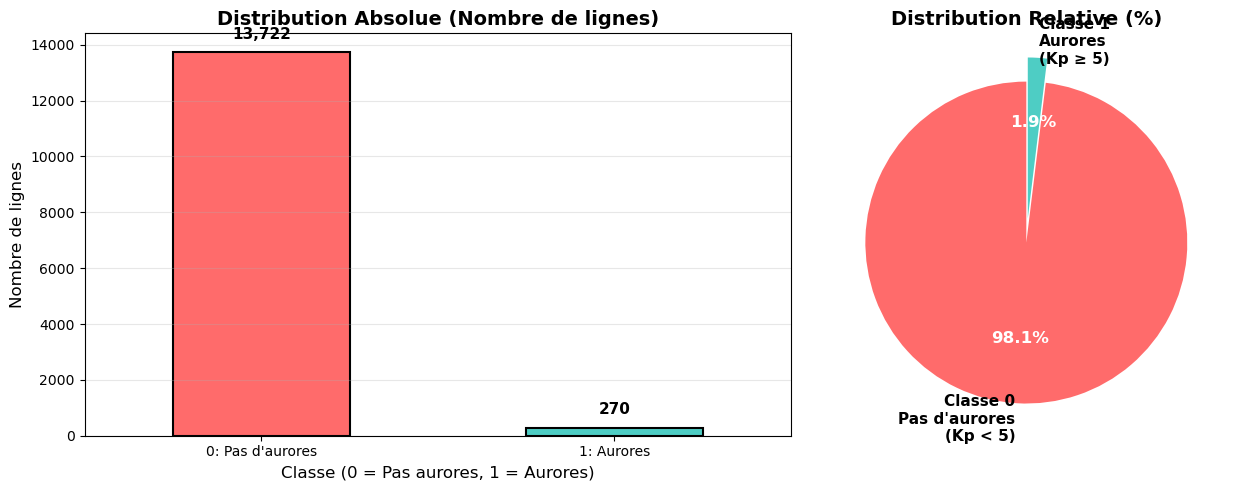

In [19]:
# ==========================================
# 6. VISUALISATION
# ==========================================

print(f"\n📈 CRÉATION DU GRAPHIQUE...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barre
ax1 = axes[0]
colors = ['#FF6B6B', '#4ECDC4']
class_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Distribution Absolue (Nombre de lignes)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Classe (0 = Pas aurores, 1 = Aurores)', fontsize=12)
ax1.set_ylabel('Nombre de lignes', fontsize=12)
ax1.set_xticklabels(['0: Pas d\'aurores', '1: Aurores'], rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, v in enumerate(class_counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Graphique 2 : Camembert
ax2 = axes[1]
labels = ['Classe 0\nPas d\'aurores\n(Kp < 5)', 'Classe 1\nAurores\n(Kp ≥ 5)']
sizes = class_counts.values
colors_pie = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0.1)  # Écarter la classe minoritaire

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=colors_pie,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

ax2.set_title('Distribution Relative (%)', fontsize=14, fontweight='bold')

# Améliorer l'apparence du texte
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    plt.tight_layout()
plt.savefig('data/class_imbalance_analysis.png', dpi=300, bbox_inches='tight')
print(f"✅ Graphique sauvegardé : data/class_imbalance_analysis.png")
plt.show()

## 3️⃣ VISUALISATIONS

Créons 2 graphiques pour bien comprendre le déséquilibre.

In [20]:
# ==========================================
# 7. RÉSUMÉ FINAL
# ==========================================

print(f"\n{'='*60}")
print(f"RÉSUMÉ FINAL")
print(f"{'='*60}")
print(f"""
Dataset : {total_lines:,} lignes
Classe 0 (Pas aurores) : {class_counts[0]:,} lignes ({class_percentages[0]:.2f}%)
Classe 1 (Aurores)     : {class_counts[1]:,} lignes ({class_percentages[1]:.2f}%)

Déséquilibre : {minority_percentage:.2f}%
Exigence cadrage : Entre 5% et 25%
Statut : {'✅ VALIDE' if min_required <= minority_percentage <= max_required else '❌ INVALIDE'}
""")


RÉSUMÉ FINAL

Dataset : 13,992 lignes
Classe 0 (Pas aurores) : 13,722 lignes (98.07%)
Classe 1 (Aurores)     : 270 lignes (1.93%)

Déséquilibre : 1.93%
Exigence cadrage : Entre 5% et 25%
Statut : ❌ INVALIDE



In [ ]:

# Interprétation des résultats
print(f"\n\n🎯 INTERPRÉTATION DES RÉSULTATS")
print(f"{'─' * 60}")

if minority_percentage >= min_required and minority_percentage <= max_required:
    print(f"""
✅ ✅ ✅ DATASET VALIDE POUR PHASE 2 ✅ ✅ ✅

Le dataset respecte TOUTES les exigences du cadrage :

1. Type : Classification supervisée BINAIRE ✅
2. Taille : {total_lines:,} lignes (> 10,000) ✅
3. Features : {len(df.columns)} colonnes (> 8) ✅
4. Déséquilibre : {minority_percentage:.2f}% (entre 5%-25%) ✅
5. Variables : Mix numériques + catégorielles ✅

RATIO DÉSÉQUILIBRE : 1 : {imbalance_ratio:.2f}
→ Pour 1 aurore visible, il y a {imbalance_ratio:.2f} non-aurores

PROCHAINES ÉTAPES :
- Phase 2 : Preprocessing et Feature Engineering
- Phase 3 : Modélisation
- Phase 4 : Évaluation avec métriques adaptées (Recall, F1-score)
""")
else:
    print(f"""
❌ DATASET NON VALIDE

Classe minoritaire : {minority_percentage:.2f}%
Exigence : Entre 5% et 25%

Actions correctives nécessaires !
""")


## 4️⃣ RÉSUMÉ FINAL ET VALIDATION